In [1]:
import kagglehub
path = kagglehub.dataset_download("emperorgraphics/hourly-load-consumption-data")

print("Path to dataset files:", path)

100%|██████████| 642k/642k [00:00<00:00, 61.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/emperorgraphics/hourly-load-consumption-data/versions/1


In [2]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/emperorgraphics/hourly-load-consumption-data/versions/1"
os.listdir(dataset_path)


['smartgrid_5yr_hourly_natural.csv']

In [3]:
import pandas as pd

path = "/root/.cache/kagglehub/datasets/emperorgraphics/hourly-load-consumption-data/versions/1/smartgrid_5yr_hourly_natural.csv"

df = pd.read_csv(path)
df.head()


,timestamp,hour,weekday,is_weekend,month,season_dry,season_rainy,season_harmattan,temperature,is_rain_day,holiday_type_national,holiday_type_religious,is_lockdown,load_kw
0,2020-01-01 00:00:00,0,2,0,1,False,False,True,25.2,0,1,0,0,36521.785383
1,2020-01-01 01:00:00,1,2,0,1,False,False,True,25.2,0,1,0,0,34934.339247
2,2020-01-01 02:00:00,2,2,0,1,False,False,True,25.2,0,1,0,0,36899.221345
3,2020-01-01 03:00:00,3,2,0,1,False,False,True,25.2,0,1,0,0,39087.574641
4,2020-01-01 04:00:00,4,2,0,1,False,False,True,25.2,0,1,0,0,34694.616563


In [4]:
df.isna().sum()

,0
timestamp,0
hour,0
weekday,0
is_weekend,0
month,0
season_dry,0
season_rainy,0
season_harmattan,0
temperature,0
is_rain_day,0


In [5]:
df.dtypes

,0
timestamp,object
hour,int64
weekday,int64
is_weekend,int64
month,int64
season_dry,bool
season_rainy,bool
season_harmattan,bool
temperature,float64
is_rain_day,int64


In [6]:
df=df.drop(columns=['timestamp'])

In [16]:
df.corr()['load_kw'].sort_values(ascending=False)

,load_kw
load_kw,1.000000
hour,0.596568
temperature,0.415026
season_dry,0.186710
season_harmattan,0.145912
holiday_type_religious,-0.070141
month,-0.073729
holiday_type_national,-0.107840
weekday,-0.181436
is_weekend,-0.221016


In [7]:
df['is_lockdown'].value_counts()
df=df.drop(columns=['is_lockdown'])

In [8]:
df['weekday'].value_counts()

,count
weekday,
2,6264
3,6264
4,6264
5,6264
6,6264
0,6264
1,6264


In [9]:
df['is_weekend'].value_counts()

,count
is_weekend,
0,31320
1,12528


In [10]:
df=df.drop(columns=['is_weekend'])

In [11]:
df.corr()['load_kw'].sort_values(ascending=False)

,load_kw
load_kw,1.000000
hour,0.596568
temperature,0.415026
season_dry,0.186710
season_harmattan,0.145912
holiday_type_religious,-0.070141
month,-0.073729
holiday_type_national,-0.107840
weekday,-0.181436
season_rainy,-0.268409


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

<Axes: xlabel='temperature', ylabel='load_kw'>

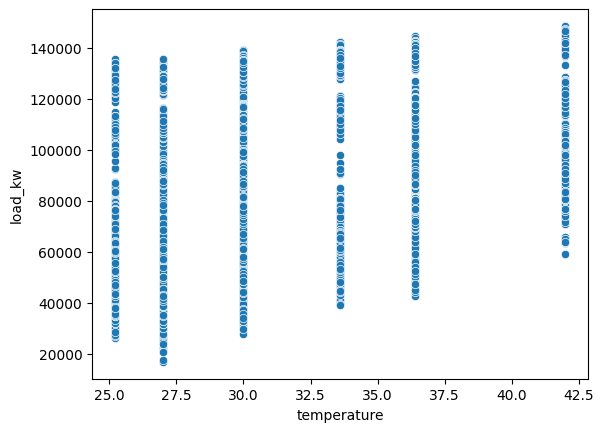

In [29]:
sns.scatterplot(x='temperature', y='load_kw', data=df)

<Axes: xlabel='weekday', ylabel='load_kw'>

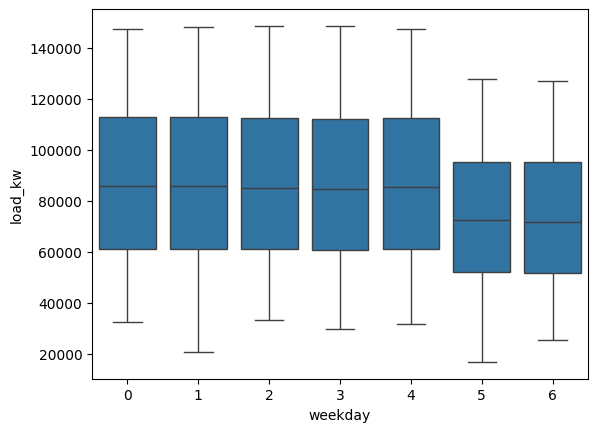

In [30]:
sns.boxplot(x='weekday', y='load_kw', data=df)

In [12]:
df=df.drop(columns=['holiday_type_religious'])
df.corr()['load_kw'].sort_values(ascending=False)
print(df.dtypes)

hour                       int64
weekday                    int64
month                      int64
season_dry                  bool
season_rainy                bool
season_harmattan            bool
temperature              float64
is_rain_day                int64
holiday_type_national      int64
load_kw                  float64
dtype: object


In [13]:
df['season_dry']=df['season_dry'].astype('int')
df['season_rainy']=df['season_rainy'].astype('int')
df['season_harmattan']=df['season_harmattan'].astype('int')

In [14]:
y=df['load_kw']
x=df.drop(columns=['load_kw'])

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [18]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [19]:
!pip install xgboost
from xgboost import XGBRegressor

In [21]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(x_train, y_train)

xgb_preds = xgb_model.predict(x_test)

print("XGBoost MAE:", mean_absolute_error(y_test, xgb_preds))
import numpy as np
rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
print("XGBoost RMSE:", rmse)



XGBoost MAE: 2236.7042735279942
XGBoost RMSE: 3192.720625230339


In [22]:
print(y.mean())
print(y.std())


82539.45541100943
27243.529137838777


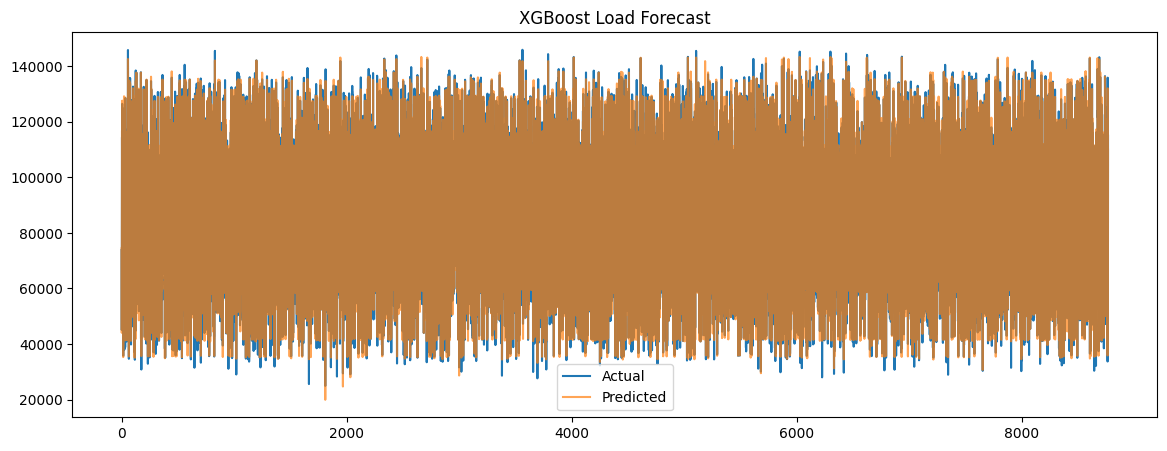

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(y_test.values, label="Actual")
plt.plot(xgb_preds, label="Predicted", alpha=0.7)
plt.legend()
plt.title("XGBoost Load Forecast")
plt.show()


In [24]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    random_state=42
)

lgbm_model.fit(x_train, y_train)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002516 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 68
[LightGBM] [Info] Number of data points in the train set: 35078, number of used features: 9
[LightGBM] [Info] Start training from score 82600.419222
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, n_estimators=1000,
              num_leaves=63, random_state=42, subsample=0.8)

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

lgbm_preds = lgbm_model.predict(x_test)

mae = mean_absolute_error(y_test, lgbm_preds)
rmse = np.sqrt(mean_squared_error(y_test, lgbm_preds))

print("LightGBM MAE:", mae)
print("LightGBM RMSE:", rmse)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM MAE: 2262.4259120065626
LightGBM RMSE: 3229.7409843237015


In [26]:
def evaluate(model, X_train, X_test, y_train, y_test, name):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"{name} MAE: {mae:.2f}")
    print(f"{name} RMSE: {rmse:.2f}\n")


In [27]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

evaluate(rf_model, x_train, x_test, y_train, y_test, "Random Forest")


Random Forest MAE: 2353.55
Random Forest RMSE: 3436.14



In [28]:
from sklearn.ensemble import ExtraTreesRegressor

et_model = ExtraTreesRegressor(
    n_estimators=500,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=42
)

evaluate(et_model, x_train, x_test, y_train, y_test, "Extra Trees")


Extra Trees MAE: 2369.90
Extra Trees RMSE: 3405.14



In [29]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=5,
    random_state=42
)

evaluate(gbr_model, x_train, x_test, y_train, y_test, "Gradient Boosting")


Gradient Boosting MAE: 2237.22
Gradient Boosting RMSE: 3192.55



In [30]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 15.7 MB/s eta 0:00:00


In [31]:
import optuna
import numpy as np
from sklearn.metrics import mean_squared_error
import pandas as pd

x_train = pd.DataFrame(x_train, columns=x.columns)
x_test  = pd.DataFrame(x_test,  columns=x.columns)

split_inner = int(len(x_train) * 0.8)

X_tr, X_val = x_train.iloc[:split_inner], x_train.iloc[split_inner:]
y_tr, y_val = y_train.iloc[:split_inner], y_train.iloc[split_inner:]


In [32]:
from xgboost import XGBRegressor
import numpy as np
from sklearn.metrics import mean_squared_error

def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 400, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 2.0),
        "objective": "reg:squarederror",
        "random_state": 42
    }

    model = XGBRegressor(**params)
    model.fit(X_tr, y_tr)

    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    return rmse


In [33]:
study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(objective_xgb, n_trials=50)

study_xgb.best_value, study_xgb.best_params


[I 2026-02-15 16:38:50,219] A new study created in memory with name: no-name-a5eedd41-be12-4568-bb76-dc3315d63ed8
[I 2026-02-15 16:38:54,367] Trial 0 finished with value: 3397.4349608312677 and parameters: {'n_estimators': 1014, 'learning_rate': 0.02876915483830806, 'max_depth': 10, 'min_child_weight': 3, 'subsample': 0.75532351414653, 'colsample_bytree': 0.9806207871721183, 'reg_alpha': 0.37889142076118276, 'reg_lambda': 1.3345726096537267}. Best is trial 0 with value: 3397.4349608312677.
[I 2026-02-15 16:38:56,270] Trial 1 finished with value: 3245.316182334034 and parameters: {'n_estimators': 848, 'learning_rate': 0.011226257172197694, 'max_depth': 7, 'min_child_weight': 4, 'subsample': 0.9557137466857804, 'colsample_bytree': 0.8439062763914448, 'reg_alpha': 0.7545686593687799, 'reg_lambda': 1.7969261170082549}. Best is trial 1 with value: 3245.316182334034.
[I 2026-02-15 16:39:01,534] Trial 2 finished with value: 3347.224743010203 and parameters: {'n_estimators': 1083, 'learning_ra

(3226.889653858246,
 {'n_estimators': 630,
  'learning_rate': 0.02943204209586919,
  'max_depth': 4,
  'min_child_weight': 8,
  'subsample': 0.9785246109930983,
  'colsample_bytree': 0.7487587410290205,
  'reg_alpha': 0.8553465647009626,
  'reg_lambda': 1.3305292485633295})

In [ ]:
x_train

,hour,weekday,month,season_dry,season_rainy,season_harmattan,temperature,is_rain_day,holiday_type_national
0,-1.520831,-1.002724,-1.310564,2.270012,-1.188913,-0.580137,0.567294,-0.580181,-0.090024
1,0.070110,0.994894,-1.310564,2.270012,-1.188913,-0.580137,2.294399,-0.580181,-0.090024
2,-0.508414,-1.002724,-1.310564,2.270012,-1.188913,-0.580137,2.294399,-0.580181,-0.090024
3,-1.665462,-0.503320,-1.600315,-0.440526,-1.188913,1.723730,-1.159811,-0.580181,-0.090024
4,-0.797676,1.494298,0.427945,-0.440526,0.841105,-0.580137,-0.172894,1.723599,-0.090024
...,...,...,...,...,...,...,...,...,...
35073,-1.520831,0.495489,0.717696,-0.440526,0.841105,-0.580137,-0.789717,1.723599,-0.090024
35074,-1.086938,-0.003915,-0.731061,-0.440526,0.841105,-0.580137,-0.789717,1.723599,-0.090024
35075,1.516419,-0.503320,-0.441310,-0.440526,0.841105,-0.580137,-0.789717,-0.580181,-0.090024
35076,1.227157,-0.503320,-1.310564,2.270012,-1.188913,-0.580137,0.567294,-0.580181,-0.090024
